# Sistemas de Controle I - Sintonia de Controladores PID pelo Método de Ziegler-Nichols

Alunos:
* Alejo Perdomo Milar
* João Mário Carnieletto Izoton Lago

---

## Efeitos dos parâmetros do Controlador PID

| Parâmetro | Tempo de Subida | Overshoot | Tempo de Estabilização | Erro em Regime |
| --------- | --------------- | --------- | ---------------------- | -------------- |
| P         | Diminui         | Aumenta   | ---                    | Diminui        |
| I         | Diminui         | Aumenta   | Aumenta                | Elimina        |
| D         | ---             | Diminui   | Diminui                | ---            |

---

## Forma do Controlador PID

<div style="display: flex; justify-content: center;">
    <img src="./assets/pid_controller.drawio.png" alt="Diagrama de blocos do sistema" width="500">
</div>

---

## Ziegler-Nichols – Método da Curva de Reação

| Controlador | $K_p$                    | $T_i = \frac{K_p}{K_i}$ | $T_d = \frac{K_d}{K_p}$ |
| ----------- | --------------------------- | ---------------------------- | ---------------------------- |
| P           | $\frac{T}{L}$             | $\infty$                   | 0                            |
| PI          | $0{,}9 \cdot \frac{T}{L}$ | $L / 0{,}3$                | 0                            |
| PID         | $1{,}2 \cdot \frac{T}{L}$ | $2L$                       | $0{,}5L$                   |

**Atenção:** Note que a tabela apresenta os parâmetros de forma interativa, ou seja, para o controlador escrito em termos de $K_p$, $T_i$ e $T_d$. Se você for implementar o controlador na forma paralela, converta-os para que o mesmo seja corretamente implementado em termos de $K_p$, $K_i$ e $K_d$!

---

## Ziegler-Nichols – Método do Ganho Crítico

| Controlador | $K_p$           | $T_i = \frac{K_p}{K_i}$ | $T_d = \frac{K_d}{K_p}$ |
| ----------- | ------------------ | ---------------------------- | ---------------------------- |
| P           | $0{,}5 K_{cr}$  | $\infty$                   | 0                            |
| PI          | $0{,}45 K_{cr}$ | $P_{cr} / 1{,}2$          | 0                            |
| PID         | $0{,}6 K_{cr}$  | $0{,}5 P_{cr}$            | $0{,}125 P_{cr}$          |

**Atenção:** Note que a tabela apresenta os parâmetros de forma interativa, ou seja, para o controlador escrito em termos de $K_p$, $T_i$ e $T_d$. Se você for implementar o controlador na forma paralela, converta-os para que o mesmo seja corretamente implementado em termos de $K_p$, $K_i$ e $K_d$!

---

# Bibliotecas e imports

In [ ]:
%pip install -q numpy matplotlib control scipy

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import scipy as sp

# Utilidades

In [17]:
def pid_controller(Kp, Ti=None, Td=None):
    s = ctrl.TransferFunction.s
    if Ti and Td:
        return Kp * (1 + 1/(Ti*s) + Td*s)
    elif Ti:
        return Kp * (1 + 1/(Ti*s))
    else:
        return Kp

def analyze_response(t, y, ref=1.0):
    y_final = y[-1]
    overshoot_val = np.max(y)
    overshoot = (overshoot_val - ref) / ref * 100  # % overshoot
    t_peak = t[np.argmax(y)]

    # Rise time (10% to 90%)
    try:
        t_10 = t[np.where(y >= 0.1 * ref)[0][0]]
        t_90 = t[np.where(y >= 0.9 * ref)[0][0]]
        rise_time = t_90 - t_10
    except IndexError:
        t_10, t_90, rise_time = np.nan, np.nan, np.nan

    # Stabilization time (±2% tolerance)
    tol = 0.02 * ref
    idx_within_tol = np.where(np.abs(y - ref) <= tol)[0]
    stabilization_time = np.nan
    if len(idx_within_tol) > 0:
        for idx in idx_within_tol:
            if np.all(np.abs(y[idx:] - ref) <= tol):
                stabilization_time = t[idx]
                break

    return {
        'rise_time': rise_time,
        't_10': t_10,
        't_90': t_90,
        'stabilization_time': stabilization_time,
        'overshoot_percent': overshoot,
        'overshoot_value': overshoot_val,
        't_peak': t_peak
    }

def plot_pi_pid_analysis(C_pi, C_pid, G1, title, x_lim=7):
    # Malha fechada
    T_pi = ctrl.feedback(C_pi * G1, 1)
    T_pid = ctrl.feedback(C_pid * G1, 1)

    # Simulação
    t = np.linspace(0, 10, 1000)
    t_pi, y_pi = ctrl.step_response(T_pi, t)
    t_pid, y_pid = ctrl.step_response(T_pid, t)

    # Análise
    results_pi = analyze_response(t_pi, y_pi)
    results_pid = analyze_response(t_pid, y_pid)

    # Plot
    plt.figure(figsize=(12, 8))
    plt.xlim(0, x_lim)

    plt.plot(t_pi, y_pi, label='PI', linewidth=2)
    plt.plot(t_pid, y_pid, label='PID', linewidth=2)

    # PI Markers
    plt.axvline(results_pi['t_10'], color='red', linestyle='--', alpha=0.6, label='PI t_10')
    plt.axvline(results_pi['t_90'], color='red', linestyle=':', alpha=0.6, label='PI t_90')
    plt.axvline(results_pi['stabilization_time'], color='blue', linestyle='-.', alpha=0.6, label='PI t_estab')
    plt.axhline(results_pi['overshoot_value'], color='blue', linestyle='--', alpha=0.3)

    # PID Markers
    plt.axvline(results_pid['t_10'], color='green', linestyle='--', alpha=0.6, label='PID t_10')
    plt.axvline(results_pid['t_90'], color='green', linestyle=':', alpha=0.6, label='PID t_90')
    plt.axvline(results_pid['stabilization_time'], color='yellow', linestyle='-.', alpha=0.6, label='PID t_estab')
    plt.axhline(results_pid['overshoot_value'], color='yellow', linestyle='--', alpha=0.3)

    # Legends with values
    text_pi = f"PI:\nRise Time = {results_pi['rise_time']:.2f}s\nEstab. Time = {results_pi['stabilization_time']:.2f}s\nOvershoot = {results_pi['overshoot_percent']:.2f}%"
    text_pid = f"PID:\nRise Time = {results_pid['rise_time']:.2f}s\nEstab. Time = {results_pid['stabilization_time']:.2f}s\nOvershoot = {results_pid['overshoot_percent']:.2f}%"

    plt.text(4, 0.4, text_pi, fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.3))
    plt.text(4, 0.7, text_pid, fontsize=10, bbox=dict(facecolor='orange', alpha=0.3))

    # Final plot details
    plt.title(title)
    plt.xlabel("Tempo (s)")
    plt.ylabel("Saída")
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.ylim([0, max(results_pi['overshoot_value'], results_pid['overshoot_value']) + 0.2])
    plt.tight_layout()
    plt.show()

# Exercícios

---

## 1.

Considere um sistema (planta) cuja função de transferência seja dada por:

$$
G_1(s) = \frac{2}{s^2 + 3s + 2}
$$

Verifique que o sistema não tem integrador na origem. Verifique também que a resposta ao degrau em malha aberta não apresenta oscilação. Isto permite a aplicação de qual método de Ziegler-Nichols?

Obtenha os parâmetros da resposta se são necessários à aplicação do método e, a partir destes valores, estabeleça os ganhos iniciais $K_p$, $T_i$ e $T_d$ para um controlador PI e um controlador PID.

Obtenha a **resposta ao degrau do sistema em malha fechada** para cada controlador (PI e PID) e determine os parâmetros desta resposta (tempo de estabilização, erro em regime, tempo de subida, se há oscilação, etc.). Compare-as com a resposta do sistema em malha aberta.

---

### Resolução

* Verificações:
  * Sistema não possui integrador na origem, pois o denominador não possui termo $s^0$ isolado.
  * Resposta ao degrau em malha aberta não apresenta oscilação -> aplicar método da curva de reação.

* Etapas:
  * Obter resposta ao degrau em malha aberta.
  * Obter parâmetros $L$ e $T$ da curva de reação.
  * Calcular $K_p$, $T_i$, $T_d$ para PI e PID.
  * Implementar controladores e plotar a resposta ao degrau em malha fechada.

### Obtenção dos parâmetros L e T

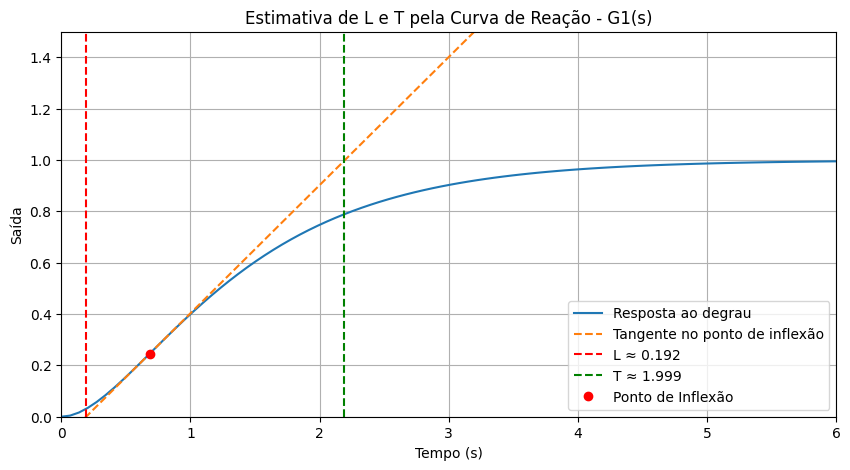

In [18]:
# Definição da planta G1(s)
num = [2]
den = [1, 3, 2]
G1 = ctrl.TransferFunction(num, den)

# Aplica resposta ao degrau
t1, y1 = ctrl.step_response(G1)
dy = np.gradient(y1, t1)

# Encontra o ponto de inflexão (máximo da derivada)
idx_inflection = np.argmax(dy)
t_inflection = t1[idx_inflection]
y_inflection = y1[idx_inflection]
slope = dy[idx_inflection]

# Equação da tangente: y = slope * (t - t_inflection) + y_inflection
tangent = slope * (t1 - t_inflection) + y_inflection

# Estimar L: quando tangente cruza y = 0
t_L = t_inflection - y_inflection / slope
L = t_L

# Estimar T: quando tangente atinge o valor final (≈ ganho da planta)
y_final = y1[-1]
t_T = (y_final - y_inflection) / slope + t_inflection
T = t_T - t_L

# Plot
plt.figure(figsize=(10, 5))
plt.xlim(0, 6)
plt.ylim(0, 1.5)

plt.plot(t1, y1, label="Resposta ao degrau")
plt.plot(t1, tangent, '--', label="Tangente no ponto de inflexão")
plt.axvline(t_L, color='red', linestyle='--', label=f"L ≈ {L:.3f}")
plt.axvline(t_T, color='green', linestyle='--', label=f"T ≈ {T:.3f}")
plt.plot(t_inflection, y_inflection, 'ro', label="Ponto de Inflexão")
plt.title("Estimativa de L e T pela Curva de Reação - G1(s)")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Contrução dos controladores PI e PID utilizando o método da Curva de Reação

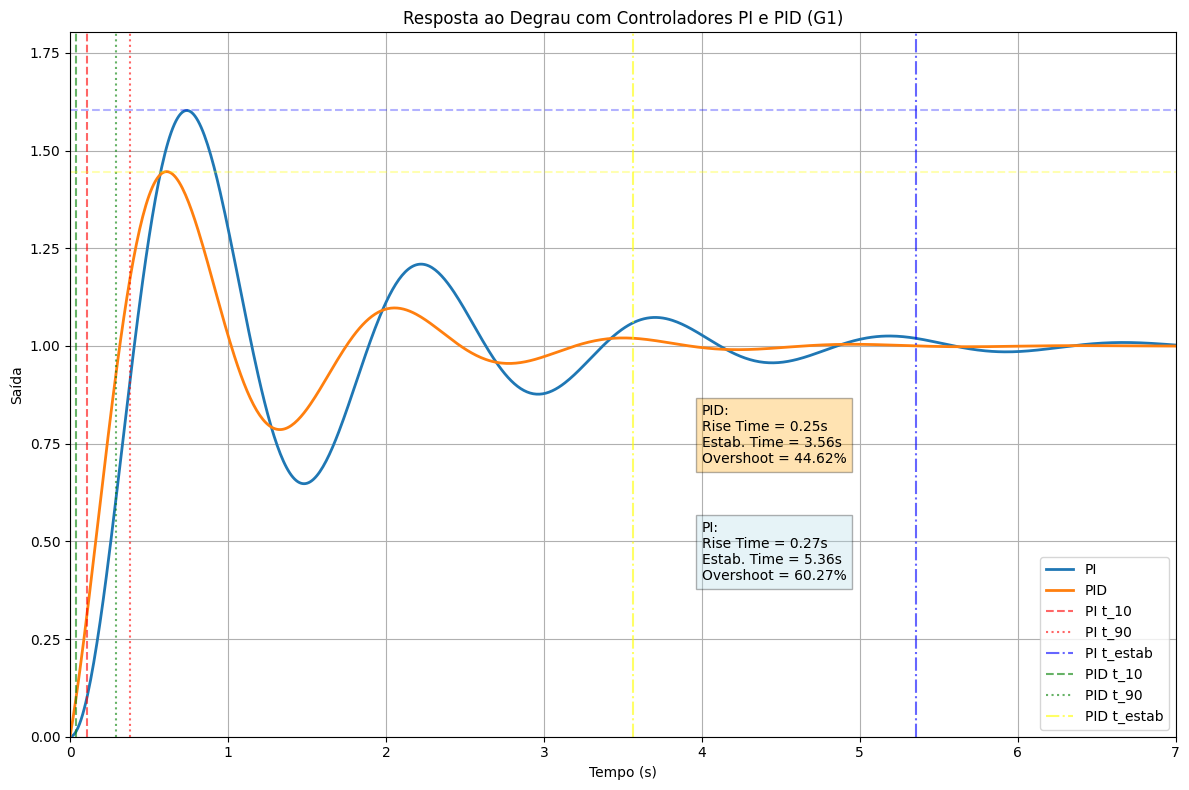

In [19]:
# Controladores utilizando o método da Curva de Reação

# Controlador PI
Kp = 0.9 * (T / L)
Ti = L / 0.3
C_pi = pid_controller(Kp, Ti)

# Controlador PID
Kp = 1.2 * (T / L)
Ti = 2.0 * L
Td = 0.5 * L
C_pid = pid_controller(Kp, Ti, Td)

plot_pi_pid_analysis(C_pi, C_pid, G1, "Resposta ao Degrau com Controladores PI e PID (G1)")

---

## 2.

Considere um sistema cuja função de transferência seja dada por:

$$
G_2(s) = \frac{1}{s(s+1)(s+5)}
$$

Deseja-se ajustar um controlador do tipo PID para o processo. Para este caso, justifique por que utilizar o método do ganho crítico.

Determine os parâmetros do método utilizando:

* (a) análise de estabilidade por Routh-Hurwitz e simulação da resposta ao degrau com o ganho crítico;
* (b) determinação analítica.

A partir destes resultados, obtenha os parâmetros iniciais dos ganhos proporcional, integral e derivativo para os controladores P, PI e PID segundo o método de Ziegler-Nichols.

Verifique a estrutura do controlador! Obtenha a **resposta ao degrau do sistema em malha fechada** com os respectivos controladores (P, PI e PID) e compare os resultados.

---

### Resolução

* Sistema possui integrador na origem -> aplicar método do ganho crítico

### Analise de estabilidade por Routh-Hurwitz

A função de transferência em malha fechada com controle proporcional será:

$$
T(s) = \frac{K_p \cdot G_2(s)}{1 + K_p \cdot G_2(s)} = \frac{K_p}{s(s+1)(s+5) + K_p}
$$

Multiplicando o denominador:

$$
s(s+1)(s+5) = s(s^2 + 6s + 5) = s^3 + 6s^2 + 5s
$$

O denominador da malha fechada torna-se:

$$
s^3 + 6s^2 + 5s + K_p
$$

### Aplicando Routh-Hurwitz à equação:

$$
s^3 + 6s^2 + 5s + K_p = 0
$$

| Potência | Linha da tabela                                                  |
| -------- | ---------------------------------------------------------------- |
| $s^3$    | $1 \quad 5$                                                      |
| $s^2$    | $6 \quad K_p$                                                    |
| $s^1$    | $\frac{6 \cdot 5 - 1 \cdot K_p}{6} = \frac{30 - K_p}{6} \quad 0$ |
| $s^0$    | $K_p$                                                            |

### Condições de estabilidade:

Para que o sistema seja **marginalmente estável (no limiar da instabilidade)**, a **primeira mudança de sinal deve ocorrer**. Isso acontece quando:

$$
\frac{30 - K_p}{6} = 0 \Rightarrow K_p = 30
$$

Logo:

* Para $K_p < 30$: todos os coeficientes da primeira coluna são positivos -> sistema **estável**.
* Para $K_p = 30$: sistema com **oscilação sustentada** -> **ganho crítico $K_{cr} = 30$**.
* Para $K_p > 30$: mudança de sinal -> sistema **instável**.


### Obtenção do ganho crítico utilizando busca iterativa

A diferença ocorre devido à forma como o ganho $K_p$ é aplicado nas duas abordagens:

* Na **análise de Routh-Hurwitz**, o ganho aparece diretamente somado no denominador da equação característica:

$$
s^3 + 6s^2 + 5s + K_p = 0
\Rightarrow K_{cr} = 30
$$

* Já na **simulação com Python**, o ganho $K_p$ multiplica a planta completa $G_2(s)$, que tem um denominador com coeficientes $s^3 + 6s^2 + 5s$. Nesse caso, a equação característica fica:

$$
T(s) = \frac{K_p}{s^3 + 6s^2 + 5s + K_p}
\Rightarrow K_{cr} \approx 5
$$

Essa diferença de escala acontece porque o termo da linha $s^1$ da tabela de Routh é:

$$
\frac{30 - K_p}{6}
$$

Logo, a correspondência entre os dois ganhos é:

$$
K_{cr,\text{Routh}} = 6 \cdot K_{cr,\text{simulação}}
\Rightarrow 30 = 6 \cdot 5
$$

No python o ganho crítico experado seria 5.

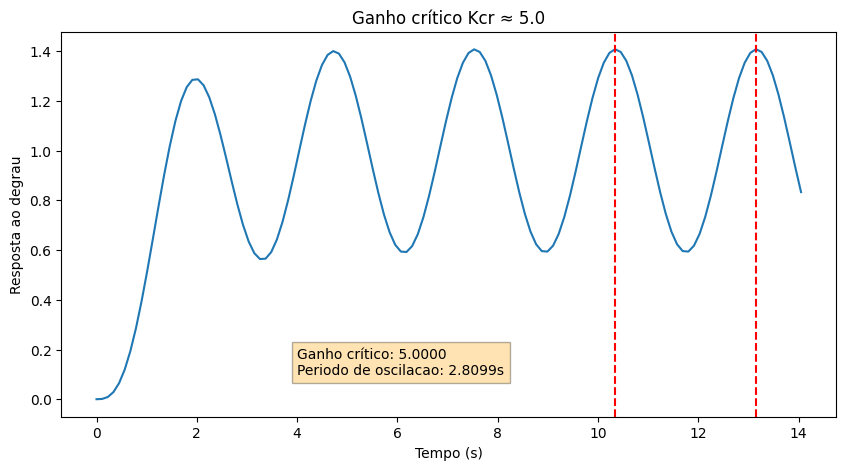

In [20]:
# Definição da planta G2(s)
G2 = ctrl.TransferFunction([1], np.convolve([1, 0], [1, 1, 5]))


# Busca iterativa do ganho crítico
Kcr = 5.0
while True:
    T = ctrl.feedback(Kcr * G2, 1)
    t, y = ctrl.step_response(T)
    if np.max(y) > 10:
        break
    Kcr += 0.01

# Parametro ajustado manualmente apos a busca iterativa e revisão para encontrar estabilidade
Kcr = 5.00
T = ctrl.feedback(Kcr * G2, 1)
t, y = ctrl.step_response(T)

# Encontra os picos de oscilacao scipy
peaks, _ = sp.signal.find_peaks(y)

# Calcula o periodo de oscilacao com base nos ultimos 2 picos
Pcr = t[peaks[-1]] - t[peaks[-2]]

# Plot resultado com Kcr iterado e ultimos 2 picos como linhas verticais
plt.figure(figsize=(10, 5))
plt.title(f"Ganho crítico Kcr ≈ {Kcr}")
plt.xlabel("Tempo (s)")
plt.ylabel("Resposta ao degrau")
plt.plot(t, y)
plt.axvline(t[peaks[-1]], color='red', linestyle='--')
plt.axvline(t[peaks[-2]], color='red', linestyle='--')

text = f"Ganho crítico: {Kcr:.4f}\nPeriodo de oscilacao: {Pcr:.4f}s"
plt.text(4, 0.1, text, fontsize=10, bbox=dict(facecolor='orange', alpha=0.3))

plt.show()


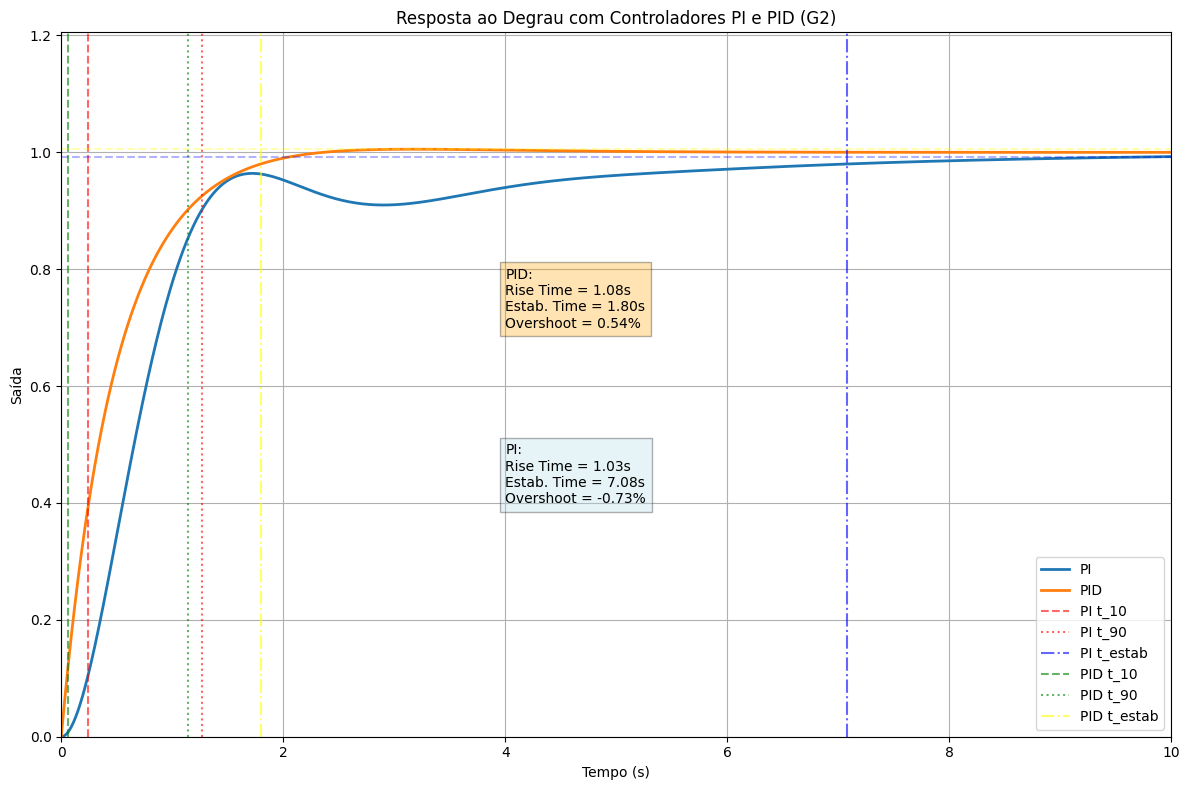

In [21]:
# Controladores utilizando o método do Ganho Crítico

# Controlador PI
Kp = 0.45 * Kcr
Ti = Pcr / 1.2
C_pi = pid_controller(Kp, Ti)

# Controlador PID
Kp = 0.6 * Kcr
Ti = 0.5 * Pcr
Td = 0.125 * Pcr
C_pid = pid_controller(Kp, Ti, Td)

plot_pi_pid_analysis(C_pi, C_pid, G1, "Resposta ao Degrau com Controladores PI e PID (G2)", x_lim=10)

## 3.

Refaça o exercício anterior considerando:

$$
G_3(s) = \frac{1}{(s+1)(s+2)(s+3)}
$$

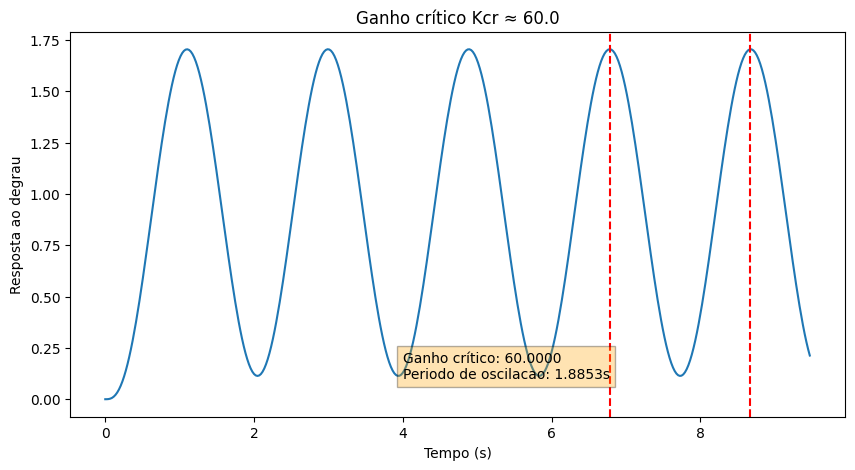

In [22]:
# Definição da planta G3(s)
G3 = ctrl.TransferFunction([1], np.convolve([1, 1], np.convolve([1, 2], [1, 3])))

# Busca iterativa do ganho crítico
Kcr = 5.0
while True:
    T = ctrl.feedback(Kcr * G3, 1)
    t, y = ctrl.step_response(T)
    if np.max(y) > 10:
        break
    Kcr += 0.2

# Parametro ajustado manualmente apos a busca iterativa e revisão para encontrar estabilidade
Kcr = 60.0
T = ctrl.feedback(Kcr * G3, 1)
t, y = ctrl.step_response(T)

# Encontra os picos de oscilacao scipy
peaks, _ = sp.signal.find_peaks(y)

# Calcula o periodo de oscilacao com base nos ultimos 2 picos
Pcr = t[peaks[-1]] - t[peaks[-2]]

# Plot resultado com Kcr iterado e ultimos 2 picos como linhas verticais
plt.figure(figsize=(10, 5))
plt.title(f"Ganho crítico Kcr ≈ {Kcr}")
plt.xlabel("Tempo (s)")
plt.ylabel("Resposta ao degrau")
plt.plot(t, y)
plt.axvline(t[peaks[-1]], color='red', linestyle='--')
plt.axvline(t[peaks[-2]], color='red', linestyle='--')

text = f"Ganho crítico: {Kcr:.4f}\nPeriodo de oscilacao: {Pcr:.4f}s"
plt.text(4, 0.1, text, fontsize=10, bbox=dict(facecolor='orange', alpha=0.3))

plt.show()


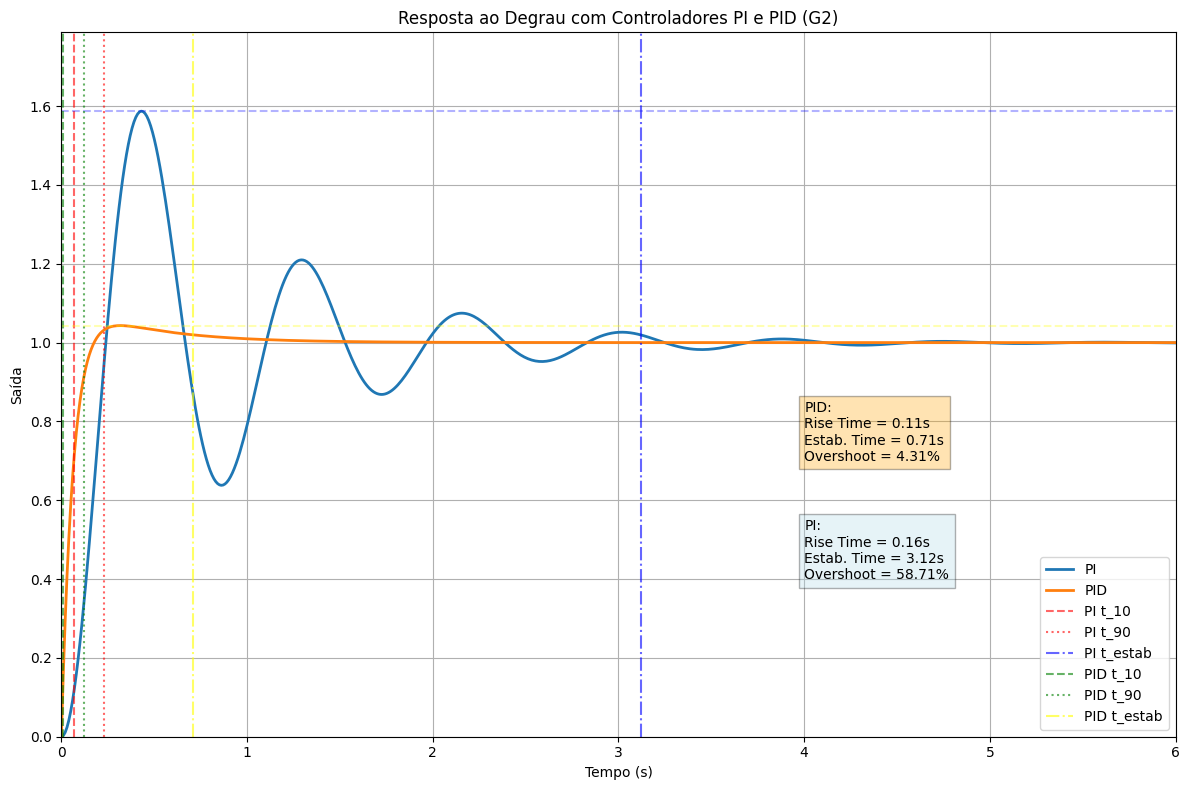

In [23]:
# Controladores utilizando o método do Ganho Crítico

# Controlador PI
Kp = 0.45 * Kcr
Ti = Pcr / 1.2
C_pi = pid_controller(Kp, Ti)

# Controlador PID
Kp = 0.6 * Kcr
Ti = 0.5 * Pcr
Td = 0.125 * Pcr
C_pid = pid_controller(Kp, Ti, Td)

plot_pi_pid_analysis(C_pi, C_pid, G1, "Resposta ao Degrau com Controladores PI e PID (G2)", x_lim=6)